# Exercise 1: CERN Staff Data (1988)
- Open an RNTuple file containing CERN staff data from 1988
- Find the number of French employees who were at least 35 years old with 1 or 2 children
- Make a histogram of their employee grade and save it to a new ROOT file
- Read it back, convert it, and plot it

Staff (ROOT::RNTuple)
├─ Category (std::int32_t)
├─ Flag (std::uint32_t)
├─ Age (std::int32_t)
├─ Service (std::int32_t)
├─ Children (std::int32_t)
├─ Grade (std::int32_t)
├─ Step (std::int32_t)
├─ Hrweek (std::int32_t)
├─ Cost (std::int32_t)
├─ Division (std::string)
└─ Nation (std::string)
Fields: ['Category', 'Flag', 'Age', 'Service', 'Children', 'Grade', 'Step', 'Hrweek', 'Cost', 'Division', 'Nation']
Number of matching employees: 839


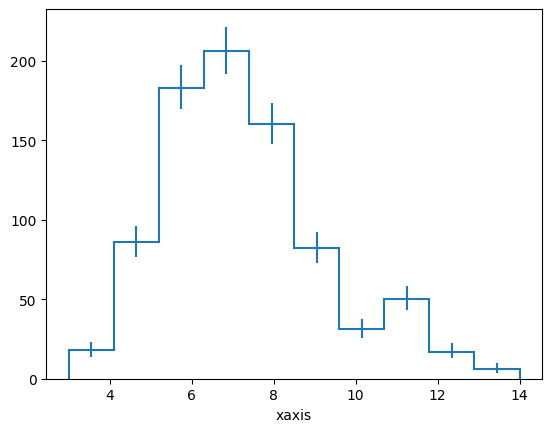

In [13]:
import uproot
import numpy as np
import skhep_testdata

filename = skhep_testdata.data_path("ntpl001_staff_rntuple_v1-0-0-0.root")

with uproot.open(filename) as f:
    staff = f["Staff"]
    staff.show()
    data = staff.arrays()

print("Fields:", data.fields)

#french employees, age >= 35, with 1 or 2 children
french_cut = data["Nation"] == "FR"
age_cut = data["Age"] >= 35
children_cut = (data["Children"] == 1) | (data["Children"] == 2)

selected = data[french_cut & age_cut & children_cut]
print(f"Number of matching employees: {len(selected)}")

#histogram of grades to new ROOT file
with uproot.recreate("exercise1_output.root") as out:
    out["grade_hist"] = np.histogram(np.array(selected["Grade"]))

#plot
with uproot.open("exercise1_output.root") as f2:
    h = f2["grade_hist"].to_hist()

h.plot();

# Exercise 2: Opposite-Charge Muon Pairs
Select pairs of muons with opposite charges and plot the dimuon mass spectrum.

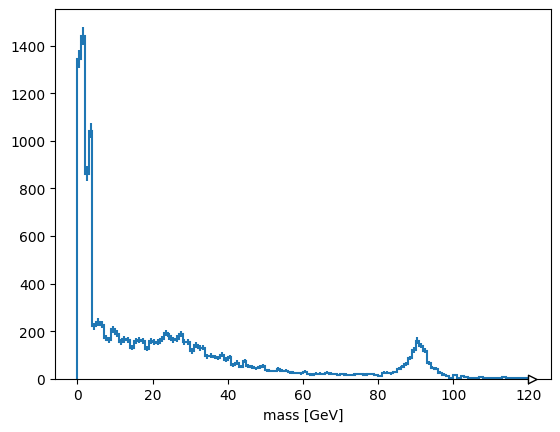

In [14]:
import uproot
import awkward as ak
import numpy as np
import hist

file = uproot.open(
    "root://eospublic.cern.ch//eos/opendata/cms/derived-data/AOD2NanoAODOutreachTool/Run2012BC_DoubleMuParked_Muons.root"
)
tree = file["Events"]

arrays = tree.arrays(filter_name="/Muon_(pt|eta|phi|charge)/", entry_stop=10_000)

muons = ak.zip({
    "pt": arrays["Muon_pt"],
    "eta": arrays["Muon_eta"],
    "phi": arrays["Muon_phi"],
    "charge": arrays["Muon_charge"],
})

#all muon pairs within each event
pairs = ak.combinations(muons, 2)
mu1, mu2 = ak.unzip(pairs)

#invariant mass for all pairs
mass = np.sqrt(
    2 * mu1.pt * mu2.pt * (np.cosh(mu1.eta - mu2.eta) - np.cos(mu1.phi - mu2.phi))
)

#only keep pairs with opposite charge
opposite_charge = mu1.charge != mu2.charge

hist.Hist(hist.axis.Regular(120, 0, 120, label="mass [GeV]")).fill(
    ak.ravel(mass[opposite_charge])
).plot();

# Exercise 3: Closest Mass to the Z Boson
For each event, find the one mass candidate that is strictly closest to the Z boson mass (91 GeV) and plot the result.

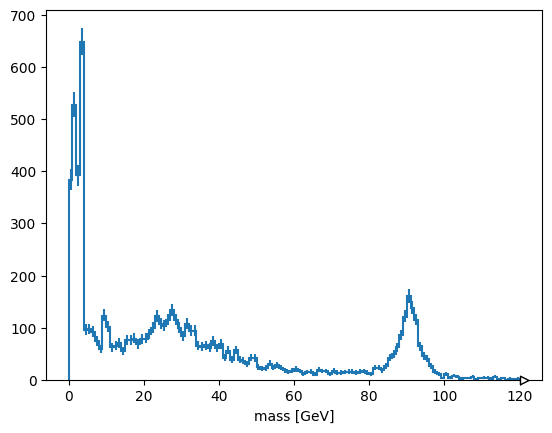

In [15]:
import particle, hepunits

zmass = particle.Particle.findall("Z0")[0].mass / hepunits.GeV

#index of the pair closest to the Z mass (for each event)
best_idx = ak.argmin(abs(mass[opposite_charge] - zmass), axis=1, keepdims=True)

#use index to pick the best mass from each event
best_mass = mass[opposite_charge][best_idx]

hist.Hist(hist.axis.Regular(120, 0, 120, label="mass [GeV]")).fill(
    ak.drop_none(ak.ravel(best_mass))
).plot();

# Extra STUFF: Dimuon Resonance Search

There was barely any questions so here is all the Scikit-HEP tools covered in one THING.

Total entries: 61,540,413
Branches available: ['nMuon', 'Muon_pt', 'Muon_eta', 'Muon_phi', 'Muon_mass', 'Muon_charge']
Processed 500,000 events, 652,193 pairs so far
Processed 1,000,000 events, 1,309,463 pairs so far
Processed 1,500,000 events, 1,963,700 pairs so far
Processed 2,000,000 events, 2,617,815 pairs so far

Total opposite-charge pairs: 2,617,815
      J/psi(1S):  mass = 3.0969 GeV,  width = 0.000093 GeV
        psi(2S):  mass = 3.6861 GeV,  width = 0.000293 GeV
    Upsilon(1S):  mass = 9.4604 GeV,  width = 0.000054 GeV
    Upsilon(2S):  mass = 10.0234 GeV,  width = 0.000032 GeV
    Upsilon(3S):  mass = 10.3551 GeV,  width = 0.000020 GeV
             Z0:  mass = 91.1880 GeV,  width = 2.495500 GeV


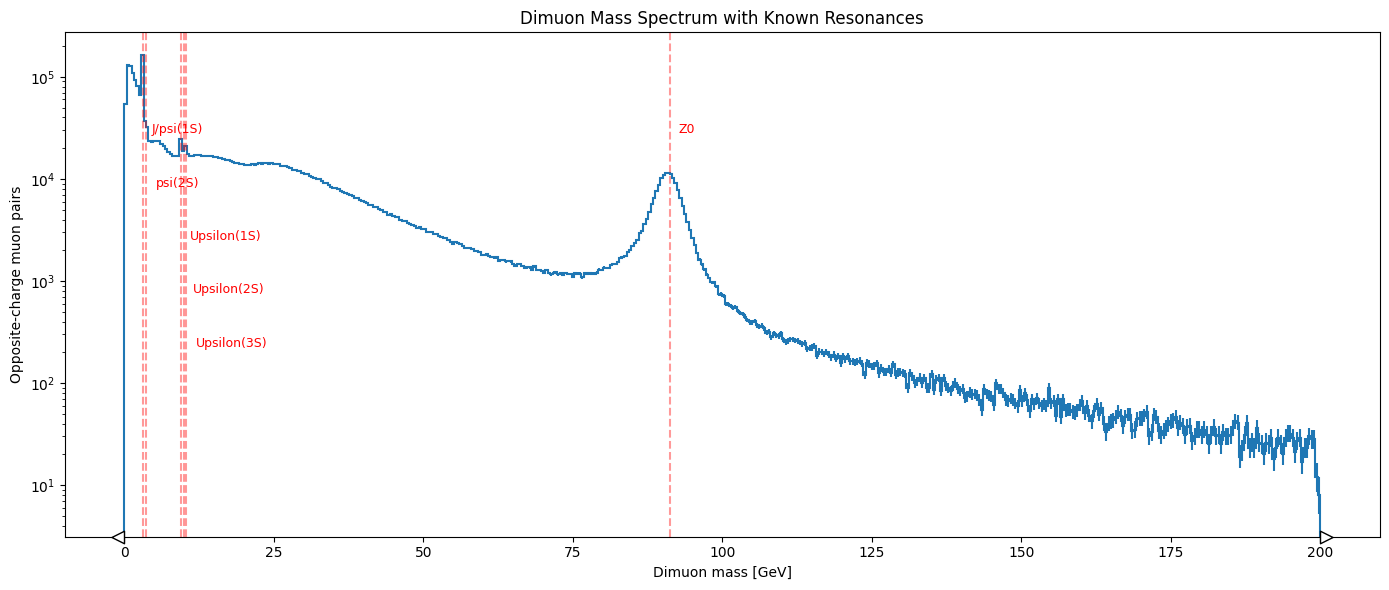

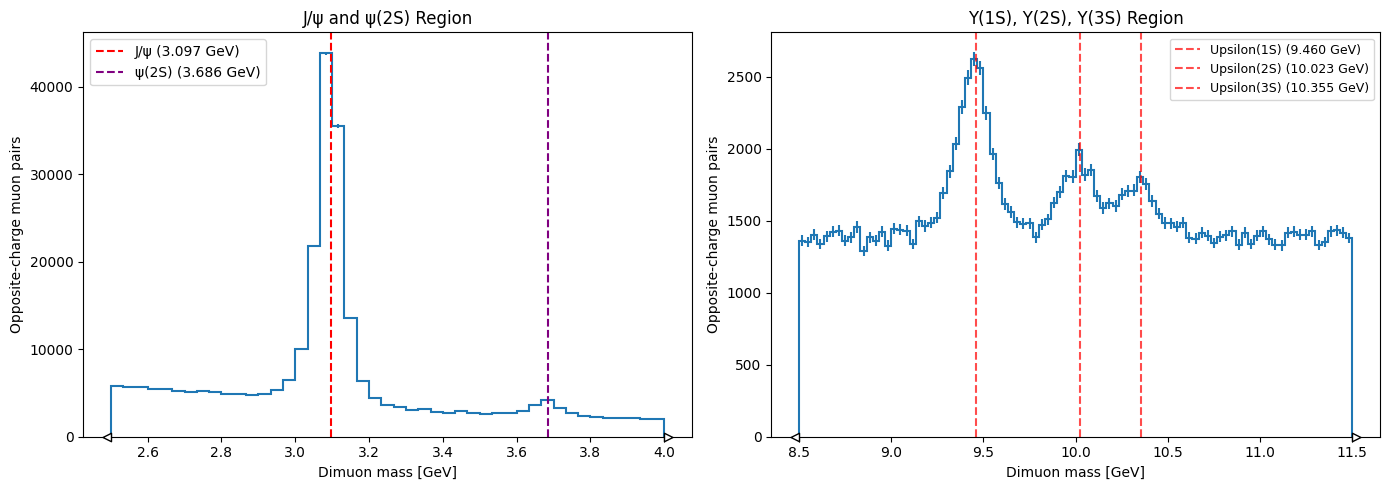

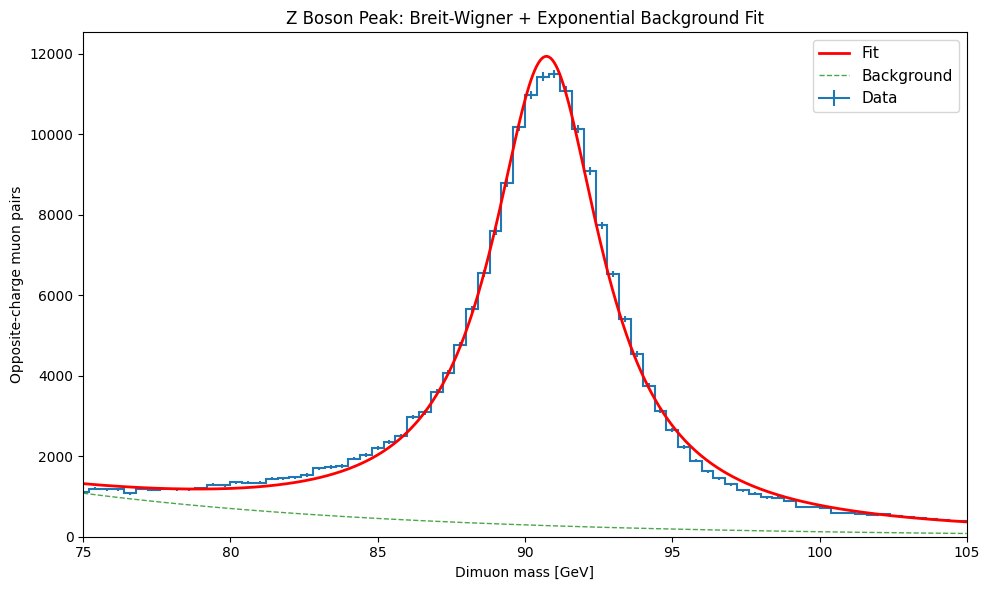


                           Fitted          PDG
          Mass [GeV]       90.734       91.188
    Width (2γ) [GeV]        4.539        2.495

CAVEATS
----------------------
This super simple fit uses a non-relativistic Breit-Wigner + an exponential
background, so it's basically only an illustrative model. The difference
from the PDG width can reflect detector resolution, binning, background
modeling, the simplified line shape, and acceptance/selection effects or just me losing patience.
A more realistic treatment would use a relativistic resonance model,
maybe with detector resolution.

This bit is mainly a Scikit-HEP demonstration (uproot,
awkward, vector, hist, particle, hepunits, iminuit), not a precision
Z-lineshape analysis.


In [16]:
import uproot
import awkward as ak
import numpy as np
import vector
import hist
import particle
from hepunits import GeV
import matplotlib.pyplot as plt

vector.register_awkward()

file = uproot.open(
    "root://eospublic.cern.ch//eos/opendata/cms/derived-data/AOD2NanoAODOutreachTool/Run2012BC_DoubleMuParked_Muons.root"
)
tree = file["Events"]

print(f"Total entries: {tree.num_entries:,}")
print(f"Branches available: {tree.keys()}")

#mass range and zoomed regions
wide_hist = hist.Hist(hist.axis.Regular(500, 0, 200, label="Dimuon mass [GeV]"))
low_mass_hist = hist.Hist(hist.axis.Regular(300, 2, 12, label="Dimuon mass [GeV]"))
z_hist = hist.Hist(hist.axis.Regular(100, 70, 110, label="Dimuon mass [GeV]"))

events_processed = 0

for arrays in tree.iterate(
    filter_name="/Muon_(pt|eta|phi|mass|charge)/",
    step_size=500_000,
    entry_stop=2_000_000,
):
    #Lorentz vectors
    muons = ak.zip(
        {
            "pt": arrays["Muon_pt"],
            "eta": arrays["Muon_eta"],
            "phi": arrays["Muon_phi"],
            "mass": arrays["Muon_mass"],
        },
        with_name="Momentum4D",
    )
    charges = arrays["Muon_charge"]

    #all pairs within each event
    mu_pairs = ak.combinations(muons, 2)
    charge_pairs = ak.combinations(charges, 2)
    mu1, mu2 = ak.unzip(mu_pairs)
    q1, q2 = ak.unzip(charge_pairs)

    #opposite charge cut
    opp_q = q1 != q2

    #Lorentz vector addition for invariant mass
    dimuon = mu1[opp_q] + mu2[opp_q]
    mass = ak.ravel(dimuon.mass)

    wide_hist.fill(mass)
    low_mass_hist.fill(mass)
    z_hist.fill(mass)

    events_processed += len(arrays)
    print(f"Processed {events_processed:,} events, {wide_hist.sum():,.0f} pairs so far")

print(f"\nTotal opposite-charge pairs: {wide_hist.sum():,.0f}")

#dimuon resonances (known)
resonances = {}
for name in ["J/psi(1S)", "psi(2S)", "Upsilon(1S)", "Upsilon(2S)", "Upsilon(3S)", "Z0"]:
    p = particle.Particle.from_name(name)
    resonances[name] = p.mass / GeV
    print(f"{name:>15s}:  mass = {p.mass/GeV:.4f} GeV,  width = {p.width/GeV:.6f} GeV")

#wide spectrum with resonances
fig, ax = plt.subplots(figsize=(14, 6))
wide_hist.plot(ax=ax)

label_positions = {
    "J/psi(1S)": (3.1, 0.85),
    "psi(2S)": (3.7, 0.75),
    "Upsilon(1S)": (9.5, 0.65),
    "Upsilon(2S)": (10, 0.55),
    "Upsilon(3S)": (10.4, 0.45),
    "Z0": (91.2, 0.85),
}

for name, m in resonances.items():
    ax.axvline(m, color="red", linestyle="--", alpha=0.4)
    xpos, yrel = label_positions[name]
    ax.text(xpos + 1.5, ax.get_ylim()[1] ** yrel, name, fontsize=9, color="red")

ax.set_yscale("log")
ax.set_title("Dimuon Mass Spectrum with Known Resonances")
ax.set_ylabel("Opposite-charge muon pairs")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#J/psi region
jpsi_region = low_mass_hist[2.5j:4j]
jpsi_region.plot(ax=axes[0])
axes[0].axvline(resonances["J/psi(1S)"], color="red", linestyle="--", label=f'J/ψ ({resonances["J/psi(1S)"]:.3f} GeV)')
axes[0].axvline(resonances["psi(2S)"], color="purple", linestyle="--", label=f'ψ(2S) ({resonances["psi(2S)"]:.3f} GeV)')
axes[0].legend()
axes[0].set_title("J/ψ and ψ(2S) Region")
axes[0].set_ylabel("Opposite-charge muon pairs")

#Upsilon region
ups_region = low_mass_hist[8.5j:11.5j]
ups_region.plot(ax=axes[1])
for name in ["Upsilon(1S)", "Upsilon(2S)", "Upsilon(3S)"]:
    axes[1].axvline(resonances[name], color="red", linestyle="--", alpha=0.7, 
                    label=f'{name} ({resonances[name]:.3f} GeV)')
axes[1].legend(fontsize=9)
axes[1].set_title("Υ(1S), Υ(2S), Υ(3S) Region")
axes[1].set_ylabel("Opposite-charge muon pairs")

plt.tight_layout()
plt.show()

import iminuit.cost

#tighter range where the fit works better (basically just cropped it to leave out the bad part)
z_region = z_hist[75j:105j]

z_data = z_region.values()
z_centres = z_region.axes[0].centers
z_err = np.sqrt(z_region.variances())
valid = z_err > 0

def signal_plus_background(x, n_sig, mu, gamma, bg_amp, bg_slope):
    #Non-relativistic Breit-Wigner (symmetric Cauchy distribution).
    #gamma here is the half-width; multiply by 2 to compare to PDG full width Γ.
    #illustrative model SEE CAVEATS PRINTED AFTER FIT.
    bw = gamma**2 / ((x - mu)**2 + gamma**2) / (np.pi * gamma)
    bg = bg_amp * np.exp(bg_slope * (x - 90))
    return n_sig * bw + bg

loss = iminuit.cost.LeastSquares(
    z_centres[valid], z_data[valid], z_err[valid], signal_plus_background
)

m = iminuit.Minuit(loss, n_sig=50000, mu=91, gamma=2, bg_amp=500, bg_slope=-0.1)
m.migrad()
m.hesse()

#full histogram but only the fit in the fitted range
fig, ax = plt.subplots(figsize=(10, 6))
z_hist.plot(ax=ax, label="Data")

x_fit = np.linspace(75, 105, 500)
ax.plot(x_fit, signal_plus_background(x_fit, *m.values), "r-", linewidth=2, label="Fit")

bg_only = m.values["bg_amp"] * np.exp(m.values["bg_slope"] * (x_fit - 90))
ax.plot(x_fit, bg_only, "g--", linewidth=1, alpha=0.7, label="Background")

ax.set_xlim(75, 105)
ax.legend(fontsize=11)
ax.set_ylabel("Opposite-charge muon pairs")
ax.set_title("Z Boson Peak: Breit-Wigner + Exponential Background Fit")
plt.tight_layout()
plt.show()

z_pdg = particle.Particle.from_name("Z0")
print(f"\n{'':>20s} {'Fitted':>12s} {'PDG':>12s}")
print(f"{'Mass [GeV]':>20s} {m.values['mu']:>12.3f} {z_pdg.mass/GeV:>12.3f}")
print(f"{'Width (2γ) [GeV]':>20s} {m.values['gamma']*2:>12.3f} {z_pdg.width/GeV:>12.3f}")
print(
    "\nCAVEATS"
    "\n----------------------"
    "\nThis super simple fit uses a non-relativistic Breit-Wigner + an exponential"
    "\nbackground, so it's basically only an illustrative model. The difference"
    "\nfrom the PDG width can reflect detector resolution, binning, background"
    "\nmodeling, the simplified line shape, and acceptance/selection effects or just me losing patience."
    "\nA more realistic treatment would use a relativistic resonance model,"
    "\nmaybe with detector resolution."
    "\n"
    "\nThis bit is mainly a Scikit-HEP demonstration (uproot,"
    "\nawkward, vector, hist, particle, hepunits, iminuit), not a precision"
    "\nZ-lineshape analysis."
)
